In [85]:
# Decision tree classifier example using scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.tree import plot_tree

In [86]:
'''ArithmeticErrordata = pd.concat([train, test], ignore_index=True)
data.replace(' ?', np.nan, inplace=True)
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)
data.drop('fnlwgt', axis=1, inplace=True)
data['income'] = data['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)
categorical_cols = data.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le
X = data.drop('income', axis=1)
y = data['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
'''

"ArithmeticErrordata = pd.concat([train, test], ignore_index=True)\ndata.replace(' ?', np.nan, inplace=True)\ndata.dropna(inplace=True)\ndata.reset_index(drop=True, inplace=True)\ndata.drop('fnlwgt', axis=1, inplace=True)\ndata['income'] = data['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)\ncategorical_cols = data.select_dtypes(include=['object']).columns\nlabel_encoders = {}\nfor col in categorical_cols:\n    le = LabelEncoder()\n    data[col] = le.fit_transform(data[col].astype(str))\n    label_encoders[col] = le\nX = data.drop('income', axis=1)\ny = data['income']\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\nscaler = StandardScaler()\nX_train = scaler.fit_transform(X_train)\nX_test = scaler.transform(X_test)\nclf = DecisionTreeClassifier(random_state=42)\nclf.fit(X_train, y_train)\ny_pred = clf.predict(X_test)\naccuracy = accuracy_score(y_test, y_pred)\nprint(f'Accuracy: {accuracy:.4f}')\nprint('Classification Report:')\npr

In [87]:
train = pd.read_csv('adult_test.csv')
test = pd.read_csv('adult_test.csv')



In [88]:
train.replace('?', np.nan, inplace = True)
test.replace('?', np.nan, inplace = True)

In [89]:
test = test.drop(columns = ['Fnlwgt'],  axis = 1)

In [90]:
train = train.drop(columns = ['Fnlwgt'],  axis = 1)

In [91]:
le = LabelEncoder()
for col in train.select_dtypes(exclude = np.number).columns:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])




    

Accuracy: 0.7685
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      1125
           1       0.77      0.76      0.76      1095

    accuracy                           0.77      2220
   macro avg       0.77      0.77      0.77      2220
weighted avg       0.77      0.77      0.77      2220



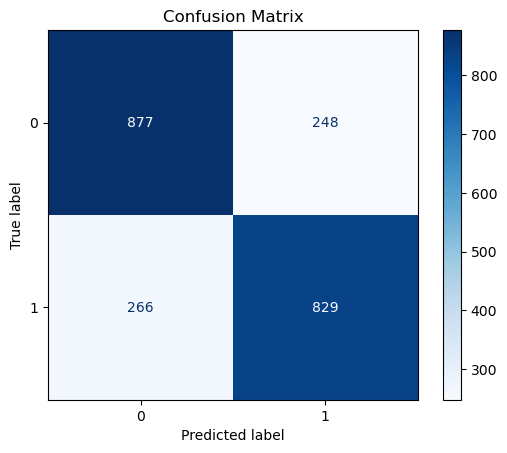

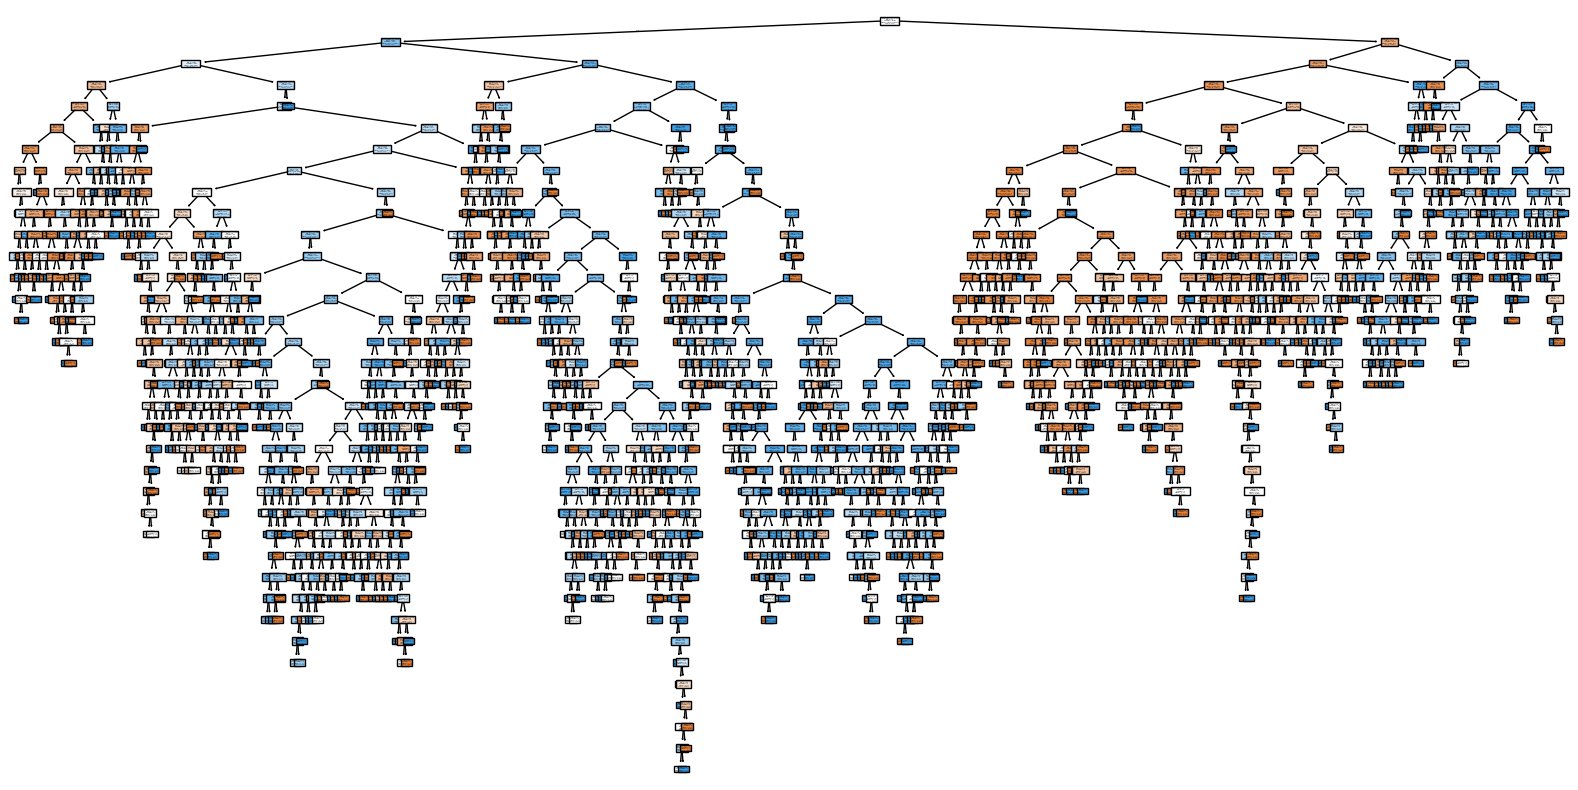

In [92]:
y = train['Label']
X = train.drop(columns = ['Label']  , axis = 1)
test_label = test['Label']
test = test.drop(columns = ['Label']  , axis = 1)
train_X, test_X, train_y, test_y = train_test_split(X,y, test_size = 0.3, random_state = 42)
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)
clf = DecisionTreeClassifier(random_state = 42)
clf.fit(train_X, train_y)
y_pred = clf.predict(test_X)

accuracy = accuracy_score (test_y, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(classification_report(test_y, y_pred))
cm = confusion_matrix(test_y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=['<=50K', '>50K'])
plt.show()


Test Data Accuracy: 0.5322
Test Data Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.89      0.66      3700
           1       0.62      0.17      0.27      3700

    accuracy                           0.53      7400
   macro avg       0.57      0.53      0.46      7400
weighted avg       0.57      0.53      0.46      7400



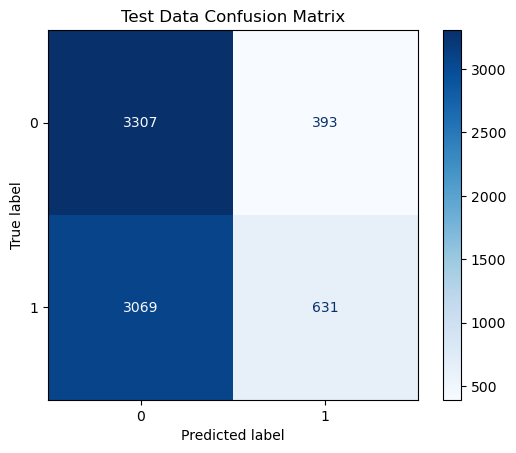

In [96]:
y_true = clf.predict(test)
accuracy_score_1 = accuracy_score (test_label, y_true)
print(f'Test Data Accuracy: {accuracy_score_1:.4f}')
print('Test Data Classification Report:')
print(classification_report(test_label, y_true))
cm_1 = confusion_matrix(test_label, y_true)
disp_1 = ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=clf.classes_)
disp_1.plot(cmap=plt.cm.Blues)
plt.title('Test Data Confusion Matrix')
plt.show()